# Step 1. EDA — SECOM 반도체 공정 데이터 탐색적 분석

**목표**: 반도체 공정 센서 데이터(SECOM)의 구조를 파악하고, 이후 전처리/모델링 전략을 세우기 위한 근거를 마련한다.

**데이터 개요**
- 1,567개 샘플(웨이퍼 단위), 590개 공정 센서 피처, 이진 레이블(정상/불량)
- 원본 레이블: `-1` = 정상(pass), `1` = 불량(fail)
- 결측치 다수 존재, 불량 비율 약 6%의 극심한 클래스 불균형

**체크리스트**
1. 데이터 shape, dtypes 확인
2. 클래스 분포(불량 vs 정상) 확인
3. 결측치 비율 컬럼별 계산 및 시각화
4. 분산 0 피처 점검
5. 피처별 분포 히스토그램

## 0. 환경 설정 및 라이브러리 import

In [1]:
# 핵심 라이브러리 import
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 그래프 한글 폰트 설정 (macOS 기준 AppleGothic)
# 주의: seaborn 스타일이 폰트를 덮어쓰므로 set_style을 먼저 호출한 뒤 폰트를 지정한다
sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'AppleGothic'  # 한글 라벨 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False   # 음수 부호(-) 깨짐 방지
plt.rcParams['figure.dpi'] = 110

# 결과 그림을 저장할 폴더 경로 (notebooks/ 기준 상위 outputs/figures)
FIG_DIR = os.path.join('..', 'outputs', 'figures')
DATA_DIR = os.path.join('..', 'data')
os.makedirs(FIG_DIR, exist_ok=True)

print('라이브러리 로드 완료')
print('pandas', pd.__version__, '| numpy', np.__version__)

라이브러리 로드 완료
pandas 2.3.3 | numpy 2.0.2


## 1. 데이터 로드

- `secom.data`: 공백으로 구분된 590개 센서 값. 결측치는 `NaN` 문자열로 기록되어 있음
- `secom_labels.data`: 첫 번째 컬럼이 레이블(-1/1), 두 번째가 측정 시각

In [2]:
# 센서 피처 데이터 로드: 공백 구분, 헤더 없음, 'NaN' 문자열을 결측치로 처리
X = pd.read_csv(
    os.path.join(DATA_DIR, 'secom.data'),
    sep=' ', header=None, na_values='NaN'
)
# 피처 이름을 sensor_000 형식으로 부여 (해석 편의성)
X.columns = [f'sensor_{i:03d}' for i in range(X.shape[1])]

# 레이블 데이터 로드: 첫 컬럼 = 레이블, 둘째 = 측정시각
labels = pd.read_csv(
    os.path.join(DATA_DIR, 'secom_labels.data'),
    sep=' ', header=None, names=['label_raw', 'timestamp']
)

# 원본 레이블(-1=정상, 1=불량)을 모델링 관습에 맞게 0/1로 변환 (1=불량, Positive)
y = labels['label_raw'].map({-1: 0, 1: 1}).rename('target')

print('X shape:', X.shape)
print('y shape:', y.shape)
X.iloc[:3, :6]

X shape: (1567, 590)
y shape: (1567,)


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0


## 2. 데이터 구조 확인 (shape, dtypes)

In [3]:
# 전체 shape 및 dtype 구성 요약
print(f'샘플 수(웨이퍼): {X.shape[0]:,}개')
print(f'피처 수(센서): {X.shape[1]:,}개')
print()
print('dtype 분포:')
print(X.dtypes.value_counts())
print()
# 수치형 피처 기술통계 일부 확인 (스케일 편차를 미리 감지)
X.describe().T[['mean', 'std', 'min', 'max']].head(8)

샘플 수(웨이퍼): 1,567개
피처 수(센서): 590개

dtype 분포:
float64    590
Name: count, dtype: int64



,mean,std,min,max
sensor_000,3014.452896,73.621787,2743.2400,3356.3500
sensor_001,2495.850231,80.407705,2158.7500,2846.4400
sensor_002,2200.547318,29.513152,2060.6600,2315.2667
sensor_003,1396.376627,441.691640,0.0000,3715.0417
sensor_004,4.197013,56.355540,0.6815,1114.5366
sensor_005,100.000000,0.000000,100.0000,100.0000
sensor_006,101.112908,6.237214,82.1311,129.2522
sensor_007,0.121822,0.008961,0.0000,0.1286


> **공정 관점 메모**: 피처마다 스케일(mean/std/min/max)이 크게 다르다. 온도·압력·유량 등 서로 다른 단위의 센서가 섞여 있음을 의미한다. → 트리 계열 모델(RF/XGB)은 스케일에 둔감하므로 별도 정규화는 필수가 아니나, SHAP 해석 시 단위 차이를 염두에 둔다.

## 3. 클래스 분포 (불량 vs 정상)

불균형의 정도를 확인한다. 이 비율이 이후 SMOTE 등 불균형 처리와 Recall 중심 평가의 근거가 된다.

클래스 분포
  정상(pass)  : 1,463개 (93.36%)
  불량(fail)  :   104개 ( 6.64%)

불균형 비율(정상:불량) ≈ 14.1 : 1


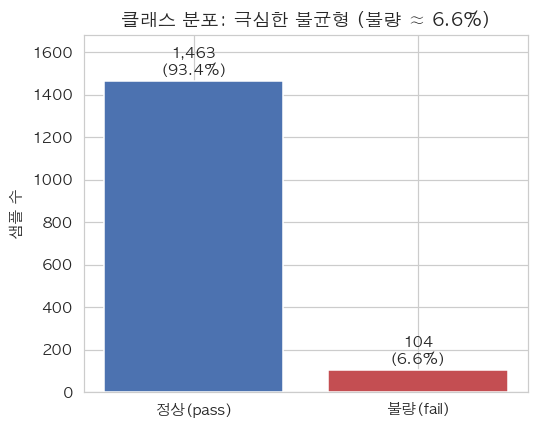

In [4]:
# 클래스별 개수와 비율 계산
counts = y.value_counts().sort_index()
ratio = y.value_counts(normalize=True).sort_index() * 100
class_names = {0: '정상(pass)', 1: '불량(fail)'}

print('클래스 분포')
for k in counts.index:
    print(f'  {class_names[k]:<10}: {counts[k]:>5,}개 ({ratio[k]:5.2f}%)')
imbalance = counts[0] / counts[1]
print(f'\n불균형 비율(정상:불량) ≈ {imbalance:.1f} : 1')

# 시각화: 막대 그래프
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar([class_names[k] for k in counts.index], counts.values,
              color=['#4C72B0', '#C44E52'])
for b, c, r in zip(bars, counts.values, ratio.values):
    ax.text(b.get_x() + b.get_width()/2, c + 15, f'{c:,}\n({r:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('클래스 분포: 극심한 불균형 (불량 ≈ 6.6%)')
ax.set_ylabel('샘플 수')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_class_distribution.png'), bbox_inches='tight')
plt.show()

> **공정 관점 메모**: 대다수 웨이퍼가 정상이고 불량은 약 6.6%만 차지한다. 이런 상황에서 Accuracy는 "모두 정상으로 찍어도 93%"가 되어 무의미하다. 불량을 놓치지 않는 것(=Recall)이 핵심이므로 **Recall / F1 / ROC-AUC** 중심으로 평가한다.

## 4. 결측치 분석

컬럼별 결측치 비율을 계산하고, 전처리 단계에서 제거할 고결측 컬럼(≈50% 이상)을 미리 파악한다.

In [5]:
# 컬럼별 결측치 비율(%) 계산
missing_ratio = (X.isna().mean() * 100).sort_values(ascending=False)

print(f'전체 결측치 셀 비율: {X.isna().mean().mean()*100:.2f}%')
print(f'결측치가 하나라도 있는 컬럼: {(missing_ratio > 0).sum()} / {X.shape[1]}개')
for thr in [10, 30, 50, 70]:
    print(f'  결측치 {thr}% 이상 컬럼: {(missing_ratio >= thr).sum()}개')

print('\n결측치 상위 10개 컬럼:')
print(missing_ratio.head(10).round(1))

전체 결측치 셀 비율: 4.54%
결측치가 하나라도 있는 컬럼: 538 / 590개
  결측치 10% 이상 컬럼: 52개
  결측치 30% 이상 컬럼: 32개
  결측치 50% 이상 컬럼: 28개
  결측치 70% 이상 컬럼: 8개

결측치 상위 10개 컬럼:
sensor_157    91.2
sensor_292    91.2
sensor_293    91.2
sensor_158    91.2
sensor_492    85.6
sensor_358    85.6
sensor_085    85.6
sensor_220    85.6
sensor_246    65.0
sensor_109    65.0
dtype: float64


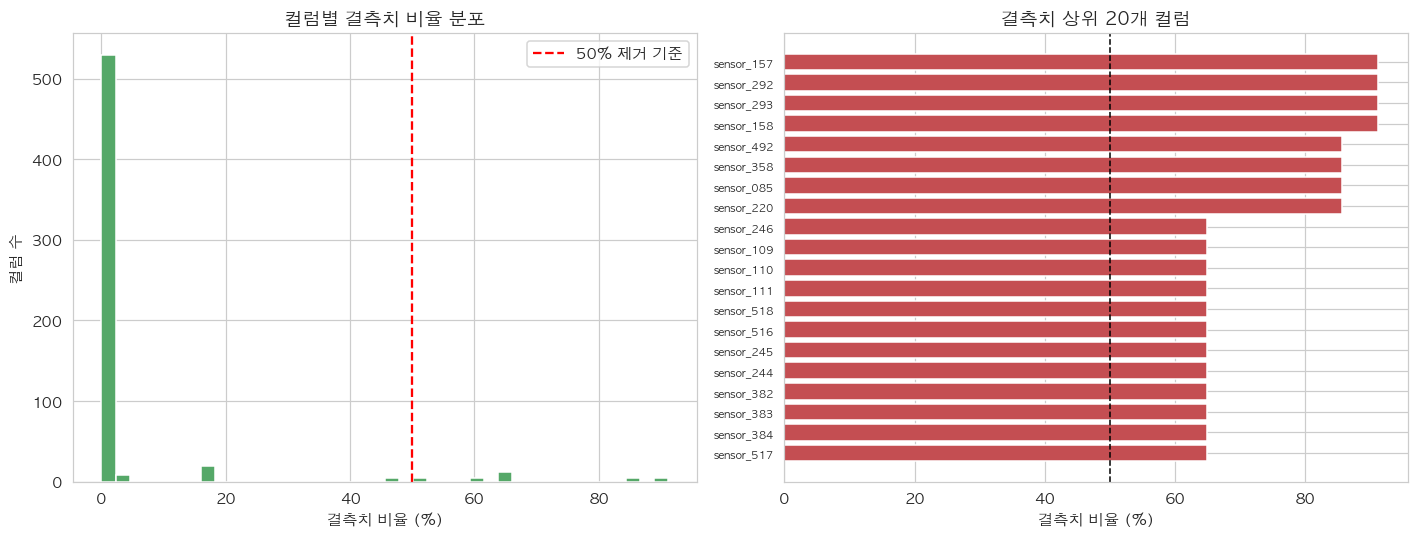

In [6]:
# 결측치 비율 시각화: (좌) 컬럼별 결측치 비율 분포, (우) 결측치 상위 20개 컬럼
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 결측치 비율 히스토그램 — 컬럼들이 어느 정도 결측치를 갖는지 분포 확인
axes[0].hist(missing_ratio.values, bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(50, color='red', linestyle='--', label='50% 제거 기준')
axes[0].set_title('컬럼별 결측치 비율 분포')
axes[0].set_xlabel('결측치 비율 (%)')
axes[0].set_ylabel('컬럼 수')
axes[0].legend()

# (우) 결측치 상위 20개 컬럼 막대
top20 = missing_ratio.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='#C44E52')
axes[1].axvline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('결측치 상위 20개 컬럼')
axes[1].set_xlabel('결측치 비율 (%)')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_missing_values.png'), bbox_inches='tight')
plt.show()

> **공정 관점 메모**: 결측치가 많은 센서는 특정 설비·공정 구간에서만 측정되었거나 센서가 간헐적으로 동작했을 가능성이 크다. 50% 이상 결측인 컬럼은 정보량이 적고 imputation 시 왜곡이 커지므로 전처리 단계에서 제거하고, 나머지는 median으로 대체한다.

## 5. 분산 0 (상수) 피처 점검

모든 웨이퍼에서 값이 동일한 센서는 불량 구분에 기여하지 못하므로 전처리에서 제거 대상이다.

In [7]:
# 결측치를 제외한 상태에서 고유값이 1개인(=분산 0) 컬럼 탐지
nunique = X.nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()
print(f'상수(분산 0) 컬럼 수: {len(constant_cols)}개')
print(f'예시: {constant_cols[:10]}')

# 분산이 거의 0에 가까운(준상수) 컬럼도 참고로 확인
near_zero = (X.std() < 1e-6).sum()
print(f'표준편차 < 1e-6 컬럼 수: {near_zero}개')

상수(분산 0) 컬럼 수: 116개
예시: ['sensor_005', 'sensor_013', 'sensor_042', 'sensor_049', 'sensor_052', 'sensor_069', 'sensor_097', 'sensor_141', 'sensor_149', 'sensor_178']
표준편차 < 1e-6 컬럼 수: 116개


## 6. 피처별 분포 히스토그램

대표 센서 몇 개의 분포를 정상/불량별로 겹쳐 확인한다. 특정 센서가 불량 구간에서 분포가 이동하는지를 미리 탐색한다.

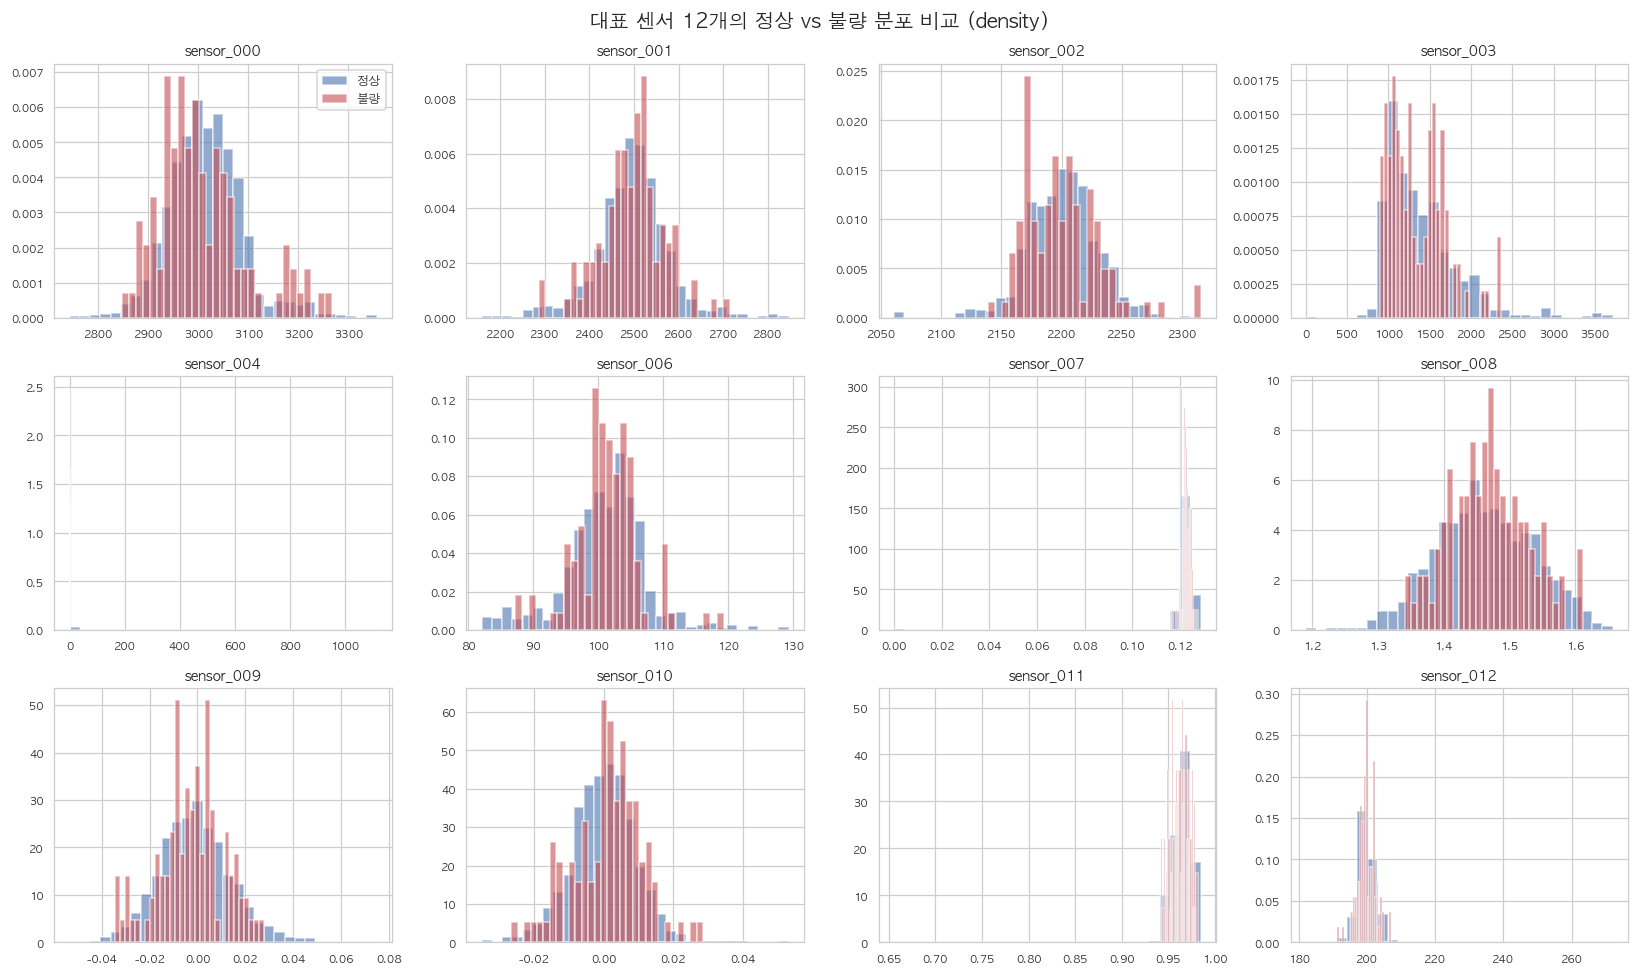

In [8]:
# 결측이 적고 분산이 있는 센서 중 앞에서 12개를 선택해 분포 확인
valid_cols = [c for c in X.columns
              if c not in constant_cols and missing_ratio[c] < 10]
sample_cols = valid_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), sample_cols):
    # 정상/불량 그룹별 분포를 겹쳐 그린다
    ax.hist(X.loc[y == 0, col].dropna(), bins=30, alpha=0.6,
            label='정상', color='#4C72B0', density=True)
    ax.hist(X.loc[y == 1, col].dropna(), bins=30, alpha=0.6,
            label='불량', color='#C44E52', density=True)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle('대표 센서 12개의 정상 vs 불량 분포 비교 (density)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_feature_distributions.png'), bbox_inches='tight')
plt.show()

> **공정 관점 메모**: 대부분의 센서는 정상/불량 분포가 거의 겹쳐 있어, 단일 센서 하나로 불량을 가르기는 어렵다. 즉 불량은 여러 공정 변수의 복합적인 조합으로 발생할 가능성이 크며, 이는 단순 규칙 대신 비선형 트리 모델(RF/XGB)과 SHAP 기반 다변수 해석이 필요한 근거가 된다.

## 7. EDA 요약 및 다음 단계 전략

In [9]:
# EDA 핵심 수치 요약 출력
print('=' * 50)
print('  SECOM EDA 요약')
print('=' * 50)
print(f'• 샘플 × 피처        : {X.shape[0]:,} × {X.shape[1]:,}')
print(f'• 불량 비율          : {ratio[1]:.2f}% (불균형 {imbalance:.1f}:1)')
print(f'• 전체 결측치 비율    : {X.isna().mean().mean()*100:.2f}%')
print(f'• 결측치 50%↑ 컬럼   : {(missing_ratio >= 50).sum()}개 (제거 예정)')
print(f'• 분산 0 컬럼        : {len(constant_cols)}개 (제거 예정)')
print(f'• 저장된 그림        : {len(os.listdir(FIG_DIR))}개 @ outputs/figures/')
print('=' * 50)

  SECOM EDA 요약
• 샘플 × 피처        : 1,567 × 590
• 불량 비율          : 6.64% (불균형 14.1:1)
• 전체 결측치 비율    : 4.54%
• 결측치 50%↑ 컬럼   : 28개 (제거 예정)
• 분산 0 컬럼        : 116개 (제거 예정)
• 저장된 그림        : 3개 @ outputs/figures/


### 포트폴리오용 인사이트 (Step 1)

- **불균형이 핵심 제약**: 불량이 전체의 6.6%에 불과해 Accuracy는 지표로 부적절하며, 불량 탐지력(Recall)과 F1, ROC-AUC를 주지표로 설정했다.
- **데이터 품질 이슈**: 결측치와 상수 센서가 존재해, 전처리에서 결측치 50%↑ 컬럼 제거 → median 대체 → 분산 0 제거 순으로 정제한다.
- **다변수 현상**: 단일 센서로는 정상/불량 분포가 구분되지 않아, 비선형 모델(RF→XGBoost)과 SHAP 해석으로 "어떤 공정 변수 조합이 불량에 기여하는가"를 분석할 계획이다.

**→ 다음 단계: `02_preprocessing.ipynb` (결측치 처리 · 분산 0 제거 · SMOTE · Train/Test 분리)**